In [20]:
import sys
import os
project_root = os.curdir
api_path = os.path.abspath(os.path.join(project_root, "API"))
if api_path not in sys.path:
	sys.path.append(api_path)

try:
	from api_key_loader import APIKeyLoader
except ImportError as e:
	print("Could not import 'api_key_loader'. Please check that './API/api_key_loader.py' exists.")
	raise e

for _ in sys.path:
	print(_)

/Users/choisoonwook/.pyenv/versions/3.12.9/lib/python312.zip
/Users/choisoonwook/.pyenv/versions/3.12.9/lib/python3.12
/Users/choisoonwook/.pyenv/versions/3.12.9/lib/python3.12/lib-dynload

/Users/choisoonwook/.pyenv/versions/qcai/lib/python3.12/site-packages
/Users/choisoonwook/Desktop/Research/quantum circuit AI/Code/API


In [21]:
key_loader = APIKeyLoader()
key_loader.help()
keylists = key_loader.key_list()

APIKeyLoader is used to load API keys from a JSON file.
You can use the following methods:
1. get_key(key): Returns the API key for the specified service.
2. key_list(): Returns a list of all available API keys.
3. help(): Prints this help message.


In [22]:
print(keylists)

['Qiskit', 'Gemini', 'Discord_Webhook', 'Discord_UID']


In [23]:
import qiskit as qk
from qiskit import QuantumCircuit, transpile
import matplotlib.pyplot as plt
from qiskit.visualization import plot_circuit_layout
from qiskit.visualization import plot_gate_map
from qiskit.visualization import plot_error_map

In [24]:
from qiskit_ibm_runtime import QiskitRuntimeService
qiskit_key = key_loader.get_key(keylists[0])
service = QiskitRuntimeService(channel="ibm_cloud", token = qiskit_key)

qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-07-16 15:03:15,882: Default instance not set. Searching all available instances.


In [25]:
backend = service.backend("ibm_fez")

In [26]:
print(backend)

<IBMBackend('ibm_fez')>


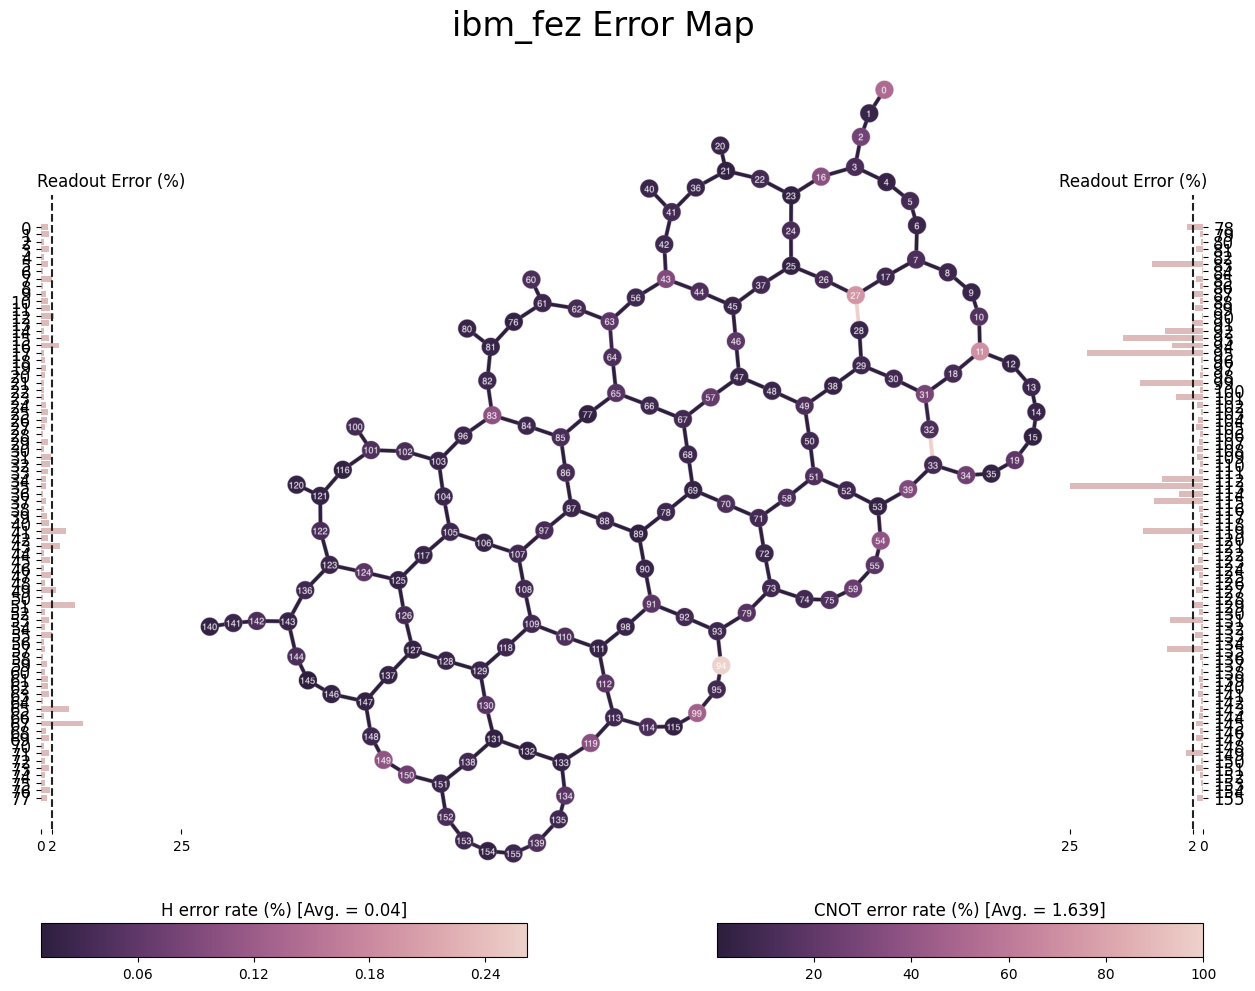

In [27]:
import graphviz
plot_error_map(backend)

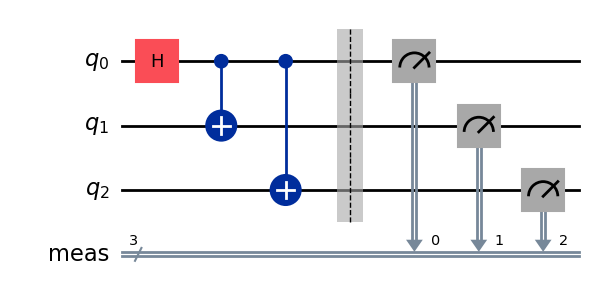

In [28]:
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime.fake_provider import *
 
# Get a fake backend from the fake provider
# Fakebackends list can be found at: https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/fake-provider
backend = FakeFez()
 
# Create a simple circuit
circuit = QuantumCircuit(3)
circuit.h(0)
circuit.cx(0,1)
circuit.cx(0,2)
circuit.measure_all()
circuit.draw('mpl', style="iqp")

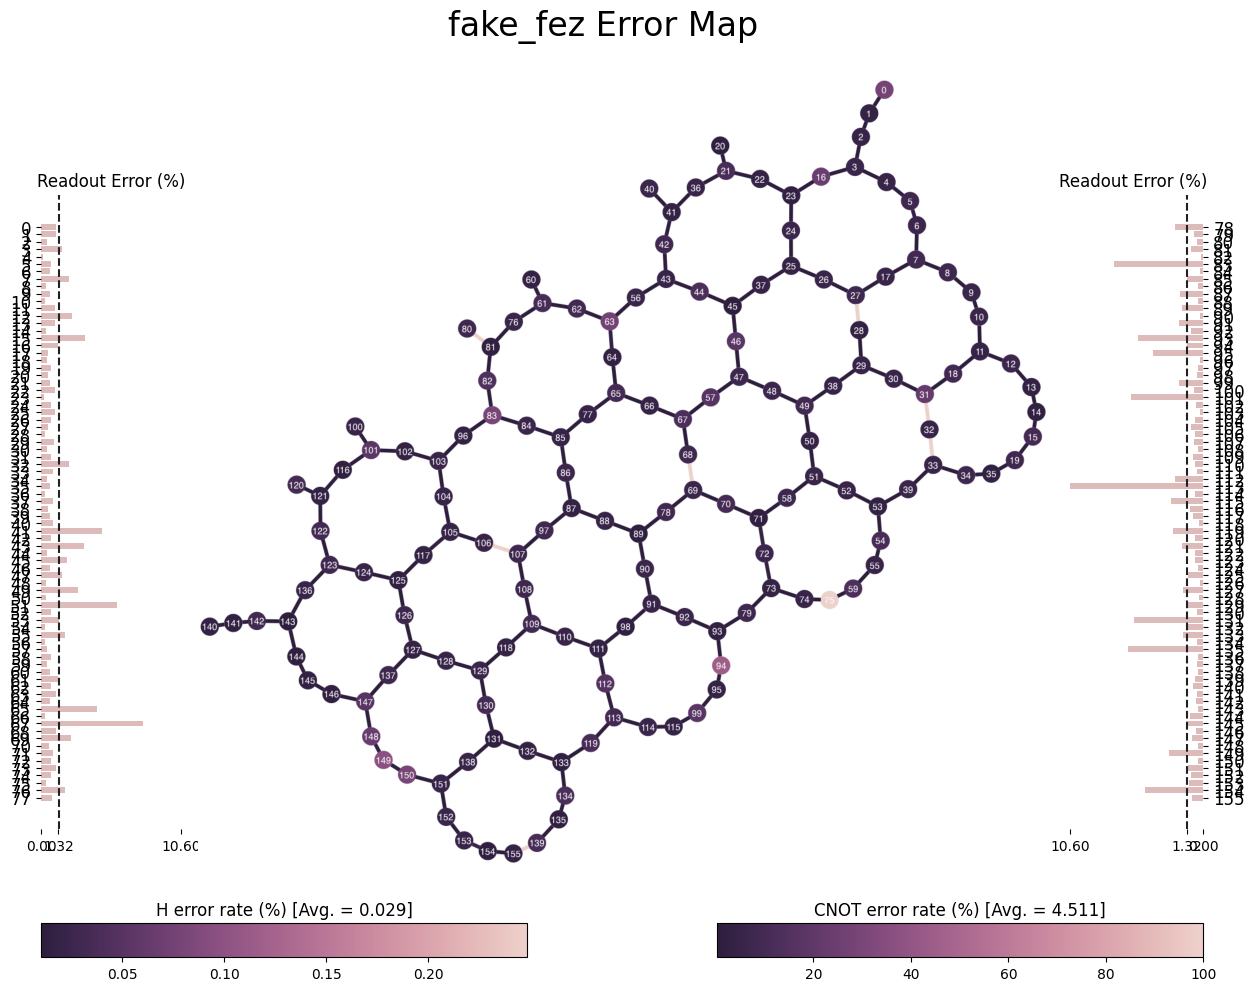

In [29]:
plot_error_map(backend) 

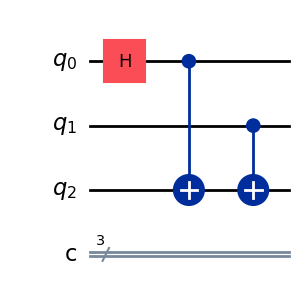

In [30]:
ex_circ = QuantumCircuit(3, 3)
ex_circ.h(0)
ex_circ.cx(0,2)
ex_circ.cx(1,2)

ex_circ.draw(output='mpl')

In [31]:
print(f"circuit depth:{ex_circ.depth()}")

circuit depth:3


In [32]:
"""
0: no optimization
1: light optimization
2: heavy optimization
3: even heavier optimization
"""
ex_circ_lv0 = transpile(ex_circ, backend=backend, optimization_level=0)
ex_circ_lv1 = transpile(ex_circ, backend=backend, optimization_level=1)
ex_circ_lv2 = transpile(ex_circ, backend=backend, optimization_level=2)
ex_circ_lv3 = transpile(ex_circ, backend=backend, optimization_level=3)
ex_circ_opt = [transpile(ex_circ, backend=backend, optimization_level=i) for i in range(4)]
for _ in ex_circ_opt:
    _.draw(output='mpl')

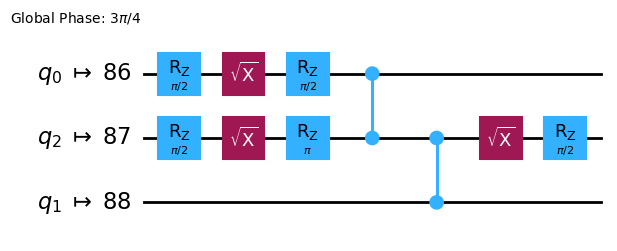

In [33]:
ex_circ_opt[3].draw(output='mpl')

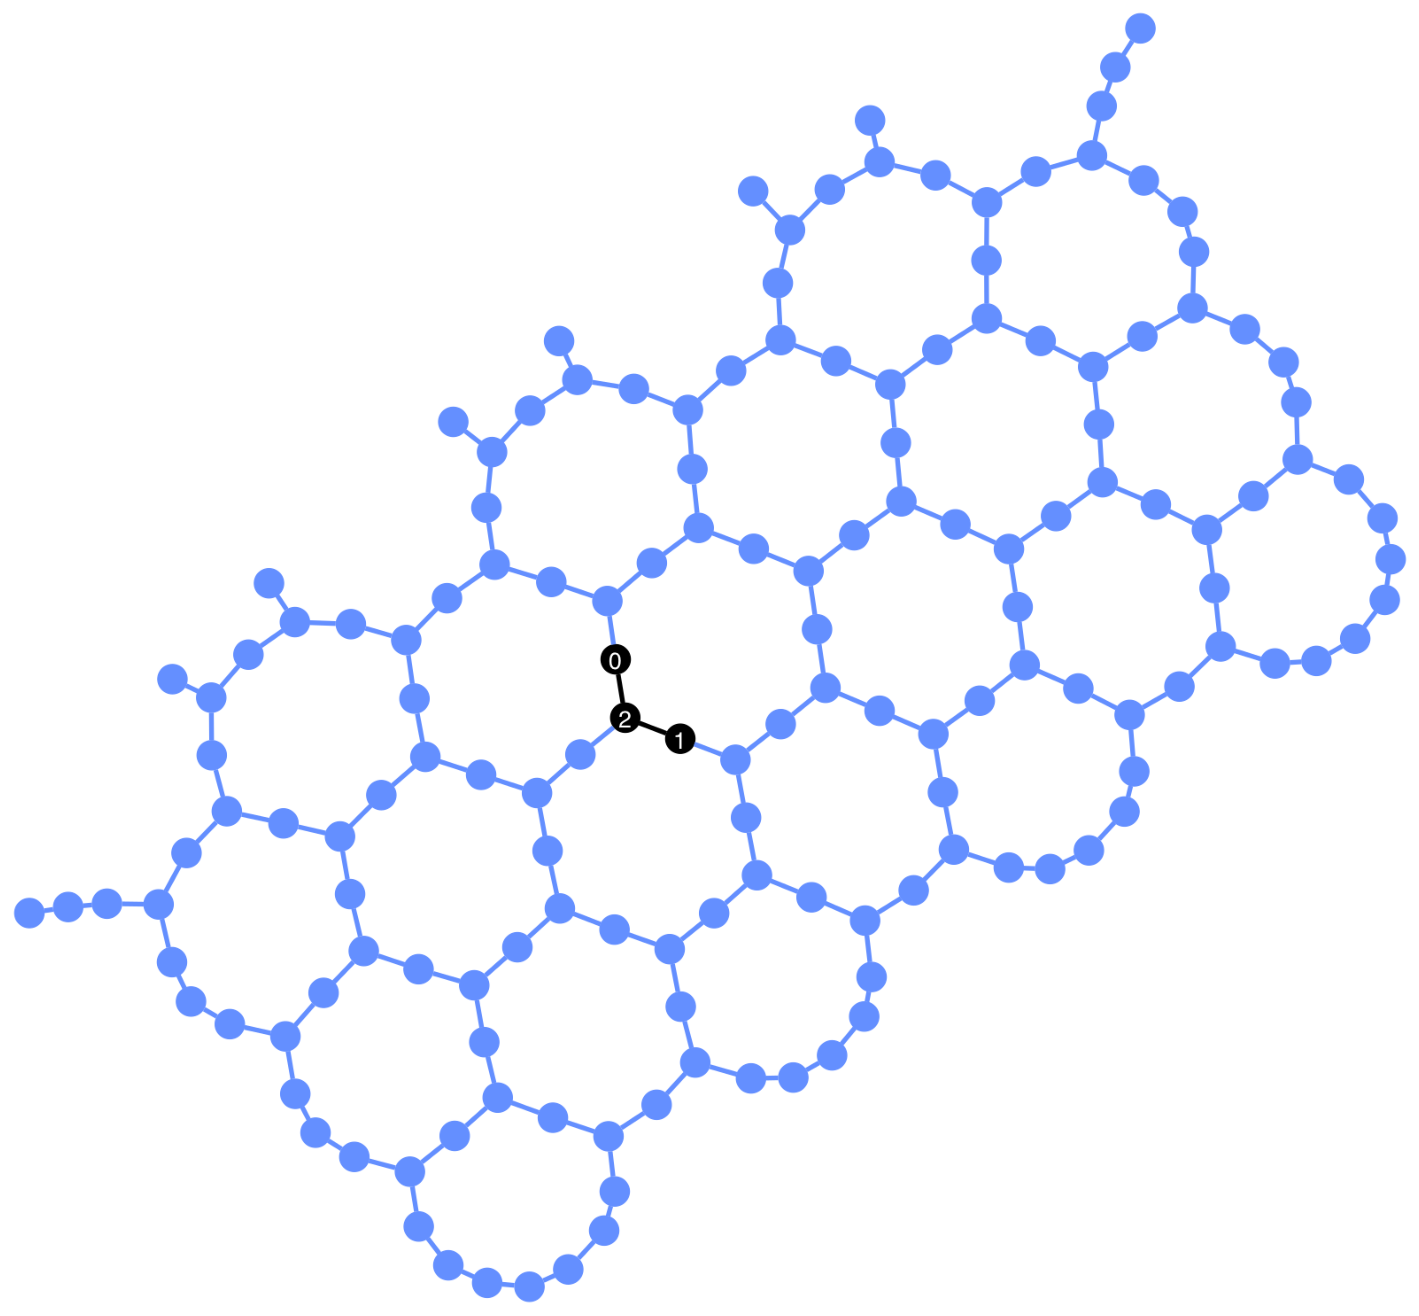

In [34]:
plot_circuit_layout(ex_circ_lv3, backend=backend)

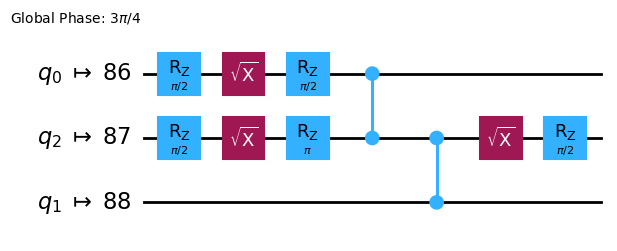

In [35]:
ex_circ_lv3.draw(output='mpl')

In [36]:
depths = []
for _ in range(100):
    depths.append(
        transpile(
            ex_circ_lv3,
            backend,
            layout_method='trivial'  # Fixed layout mapped in circuit order
        ).depth()
    )

Text(0, 0.5, 'Counts')

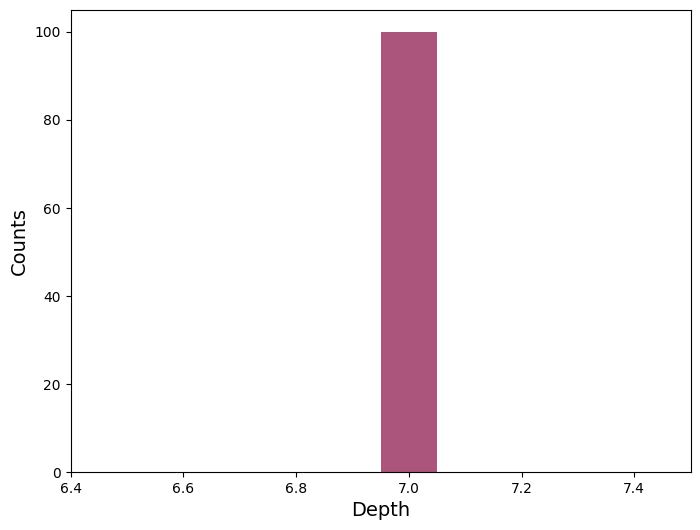

In [37]:
plt.figure(figsize=(8, 6))
plt.hist(depths, align='left', color='#AC557C')
plt.xlabel('Depth', fontsize=14)
plt.ylabel('Counts', fontsize=14)

In [38]:
ex_circ_my = transpile(ex_circ, backend=backend, initial_layout=[0, 1, 4])

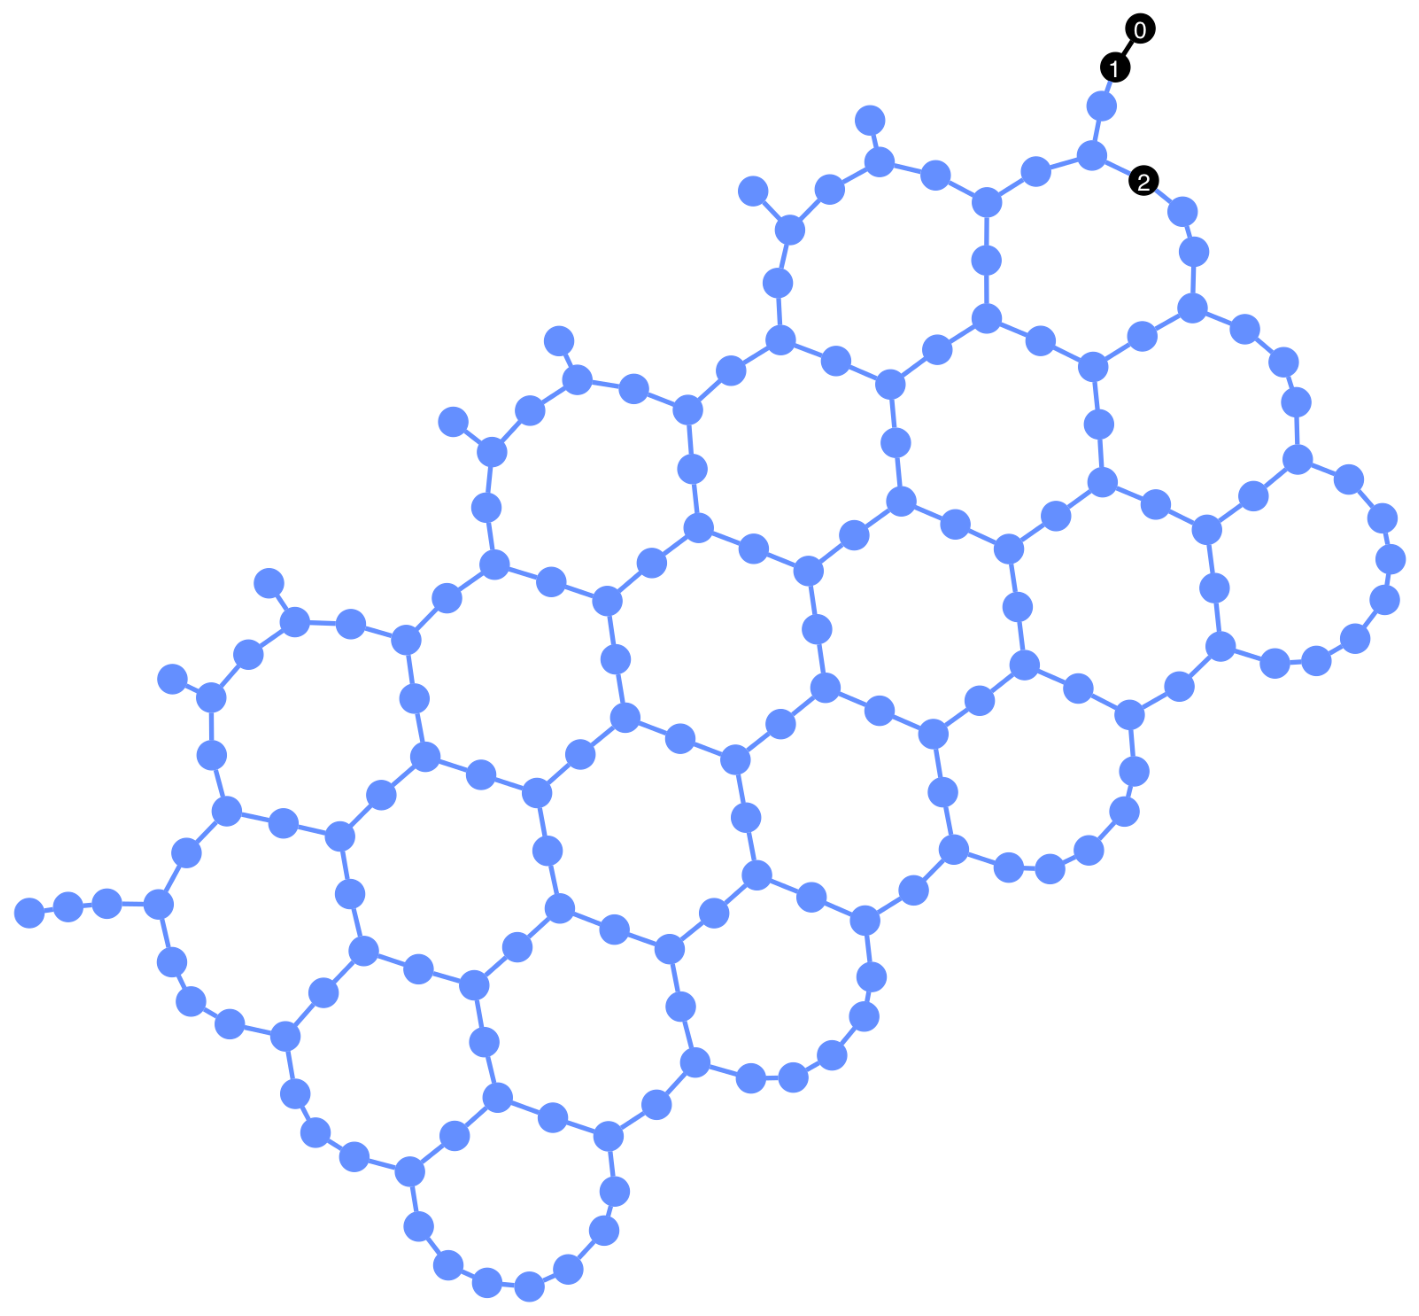

In [39]:
plot_circuit_layout(ex_circ_my, backend)

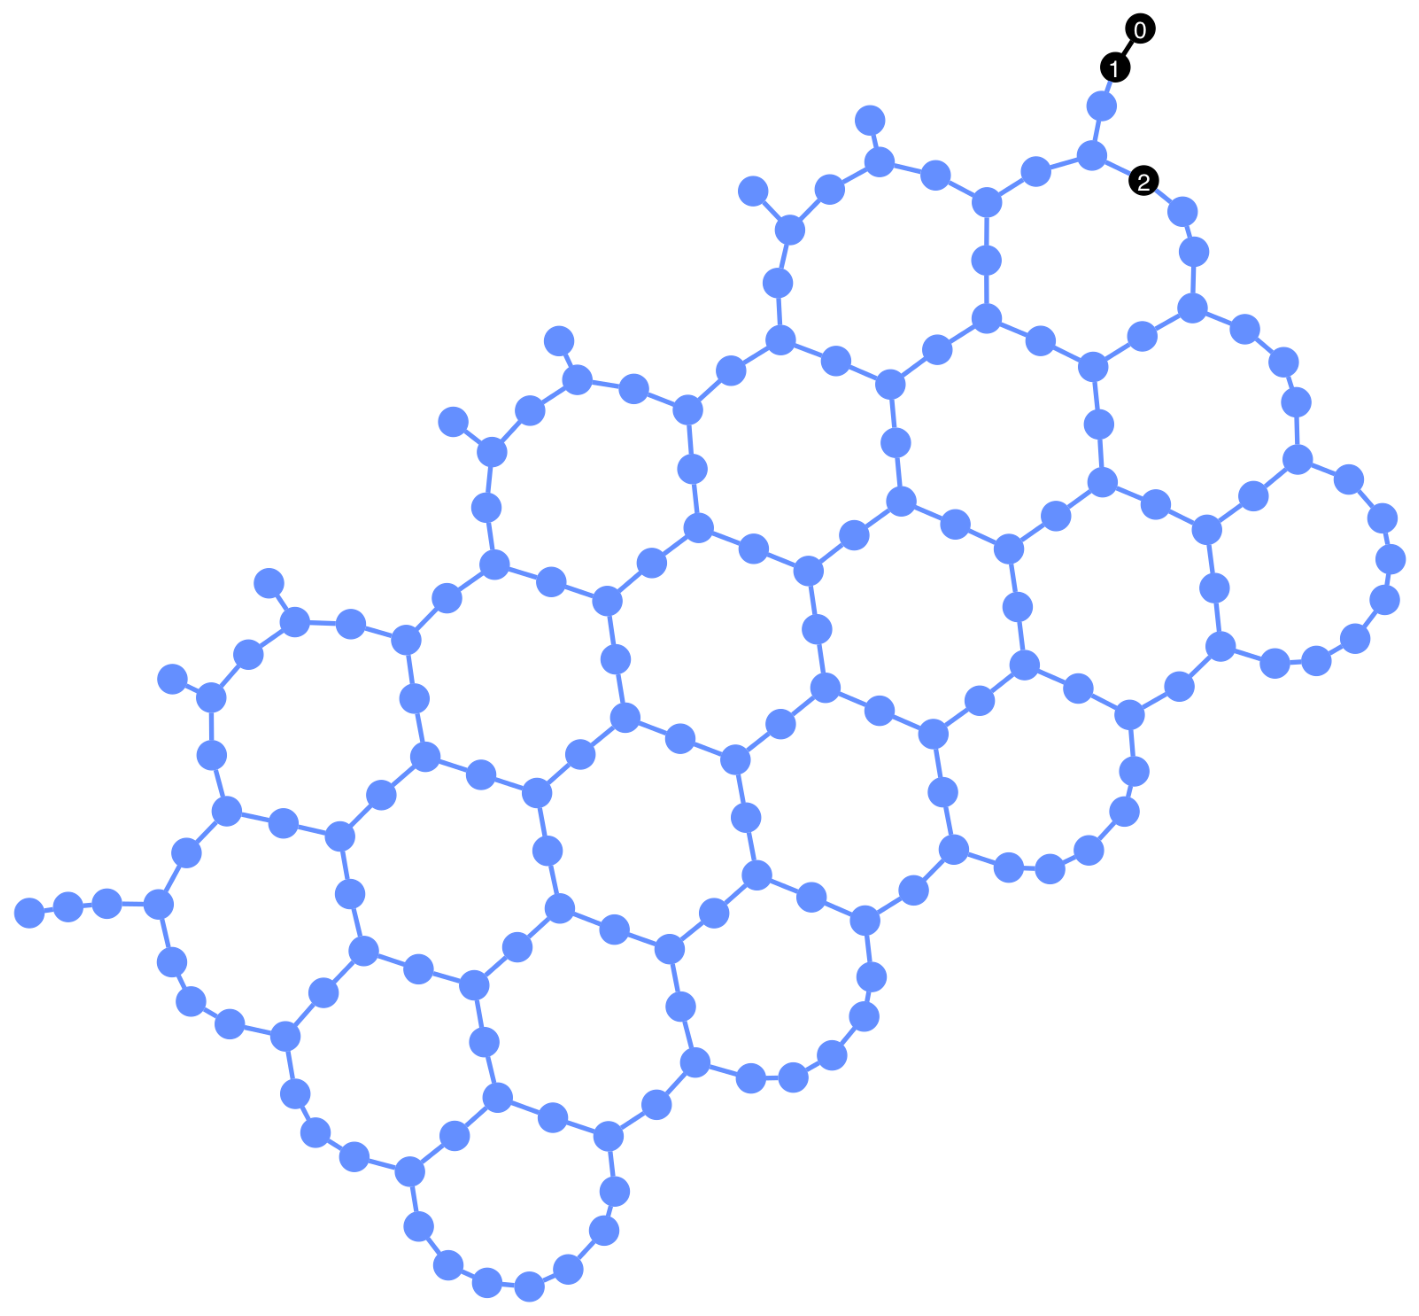

In [40]:
plot_circuit_layout(ex_circ_my, backend)

In [41]:
depths = []
for _ in range(100):
    depths.append(
        transpile(
            ex_circ_my,
            backend,
            layout_method='trivial'  # Fixed layout mapped in circuit order
        ).depth()
    )

Text(0, 0.5, 'Counts')

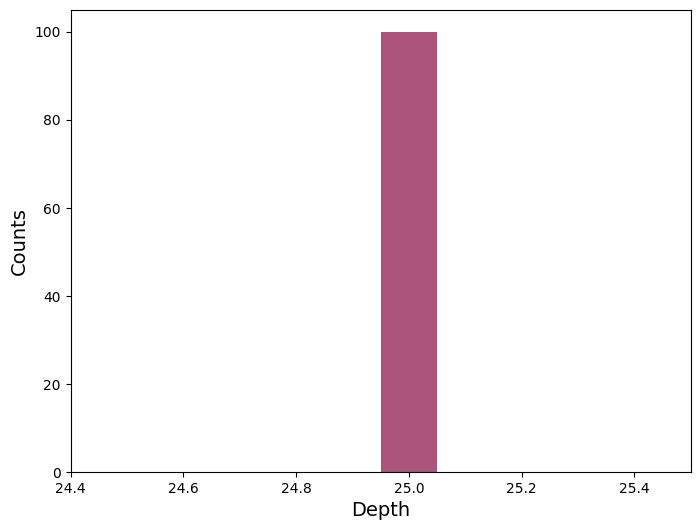

In [42]:
plt.figure(figsize=(8, 6))
plt.hist(depths, align='left', color='#AC557C')
plt.xlabel('Depth', fontsize=14)
plt.ylabel('Counts', fontsize=14)